<a href="https://colab.research.google.com/github/Sitthisak17SM/Super_AI/blob/main/Heart_Disease_Prediction_600817.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os, csv, re, time, requests
import numpy as np
import pandas as pd
from pathlib import Path
from google.colab import userdata

# Data

KAGGLE_API_KEY = userdata.get('KAGGLE_API')
os.environ['KAGGLE_API_TOKEN'] = KAGGLE_API_KEY
!kaggle competitions download -c super-ai-engineer-ss-6-heart-disease-prediction
!unzip -q super-ai-engineer-ss-6-heart-disease-prediction

100% 4.30M/4.30M [00:00<00:00, 40.7MB/s]



In [ ]:
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')
sample_sub = pd.read_csv('sample_submission.csv')

In [ ]:
print(f"📌 ขนาดของ Train set: {train_df.shape}")
print(f"📌 ขนาดของ Test set: {test_df.shape}")
print("-" * 40)

📌 ขนาดของ Train set: (223084, 20)
📌 ขนาดของ Test set: (74361, 19)
----------------------------------------


In [ ]:
print("\n🔍 ตัวอย่างข้อมูล 5 แถวแรกของ Train set:")
display(train_df.head())


🔍 ตัวอย่างข้อมูล 5 แถวแรกของ Train set:


,ID,History of HeartDisease or Attack,High Blood Pressure,Told High Cholesterol,Cholesterol Checked,Body Mass Index,Smoked 100+ Cigarettes,Diagnosed Stroke,Diagnosed Diabetes,Leisure Physical Activity,Heavy Alcohol Consumption,Health Care Coverage,Doctor Visit Cost Barrier,General Health,Difficulty Walking,Sex,Education Level,Income Level,Age,Vegetable or Fruit Intake (1+ per Day)
0,train_000001,No,Yes,Yes,Yes,40.68,Yes,No,No,No,No,Yes,No,Very Poor,Yes,Female,High school graduate,"$15,000 to less than $20,000",64,Yes
1,train_000002,No,No,No,No,24.36,Yes,No,No,Yes,No,No,Yes,Fair,No,Female,College graduate,"Less than $10,000",50,No
2,train_000003,No,Yes,Yes,Yes,27.33,No,No,No,No,No,Yes,Yes,Very Poor,Yes,Female,High school graduate,"$75,000 or more",61,Yes
3,train_000004,No,Yes,No,Yes,27.01,No,No,No,Yes,No,Yes,No,Good,No,Female,Some high school,"$35,000 to less than $50,000",74,Yes
4,train_000005,NaN,Yes,Yes,Yes,34.56,Yes,No,No,Yes,No,Yes,Yes,Very Poor,Yes,Male,Some high school,"$15,000 to less than $20,000",98,Yes


In [ ]:
# 4. ดูภาพรวมของประเภทข้อมูล (Data Types) และจำนวนข้อมูลที่ไม่ใช่ค่าว่าง
print("\n📊 ข้อมูลสรุปของ Train set (Data Types & Non-Null Count):")
train_df.info()


📊 ข้อมูลสรุปของ Train set (Data Types & Non-Null Count):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 223084 entries, 0 to 223083
Data columns (total 20 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   ID                                      223084 non-null  object 
 1   History of HeartDisease or Attack       221390 non-null  object 
 2   High Blood Pressure                     223084 non-null  object 
 3   Told High Cholesterol                   190898 non-null  object 
 4   Cholesterol Checked                     223084 non-null  object 
 5   Body Mass Index                         211302 non-null  float64
 6   Smoked 100+ Cigarettes                  223083 non-null  object 
 7   Diagnosed Stroke                        223084 non-null  object 
 8   Diagnosed Diabetes                      223081 non-null  object 
 9   Leisure Physical Activity               223084 non-null 

In [ ]:
# 5. ตรวจสอบหาค่าว่าง (Missing Values) ในแต่ละคอลัมน์
print("\n⚠️ จำนวนค่าว่าง (Missing Values) ในแต่ละคอลัมน์ (Train set):")
missing_values = train_df.isnull().sum()
# แสดงเฉพาะคอลัมน์ที่มีค่าว่าง
print(missing_values[missing_values > 0])


⚠️ จำนวนค่าว่าง (Missing Values) ในแต่ละคอลัมน์ (Train set):
History of HeartDisease or Attack     1694
Told High Cholesterol                32186
Body Mass Index                      11782
Smoked 100+ Cigarettes                   1
Diagnosed Diabetes                       3
Doctor Visit Cost Barrier                1
General Health                           1
Difficulty Walking                       3
dtype: int64


/tmp/ipykernel_3066/3561956499.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_df, x='History of HeartDisease or Attack', palette='viridis')


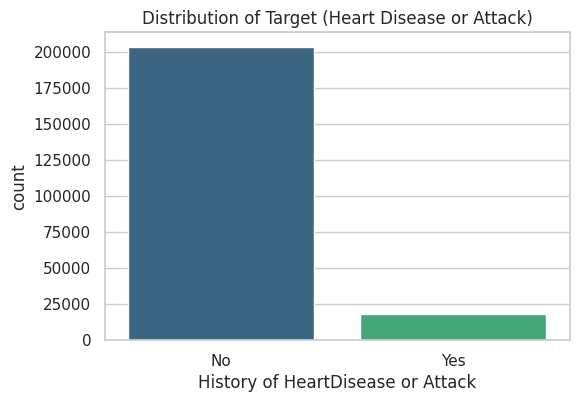

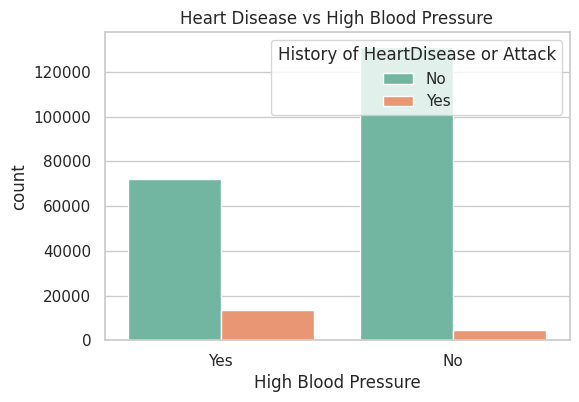

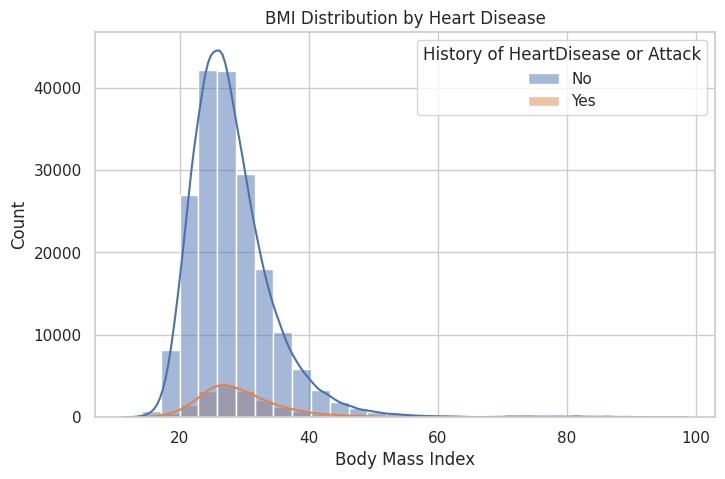

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# ตั้งค่าสไตล์กราฟให้ดูสะอาดตา
sns.set_theme(style="whitegrid")

# 1. พล็อตดูสัดส่วนของคนที่มีและไม่มีประวัติโรคหัวใจ (Target Variable)
plt.figure(figsize=(6, 4))
sns.countplot(data=train_df, x='History of HeartDisease or Attack', palette='viridis')
plt.title('Distribution of Target (Heart Disease or Attack)')
plt.show()

# 2. เปรียบเทียบความสัมพันธ์ระหว่าง "ความดันโลหิตสูง" กับ "โรคหัวใจ"
plt.figure(figsize=(6, 4))
sns.countplot(data=train_df, x='High Blood Pressure', hue='History of HeartDisease or Attack', palette='Set2')
plt.title('Heart Disease vs High Blood Pressure')
plt.show()

# 3. ดูการกระจายตัวของตัวเลข (เช่น ค่าดัชนีมวลกาย - BMI) แบ่งตามกลุ่มโรคหัวใจ
plt.figure(figsize=(8, 5))
sns.histplot(data=train_df, x='Body Mass Index', hue='History of HeartDisease or Attack', kde=True, bins=30)
plt.title('BMI Distribution by Heart Disease')
plt.show()

📊 กำลังพล็อตตัวแปรที่เป็นตัวเลข (Numeric)...


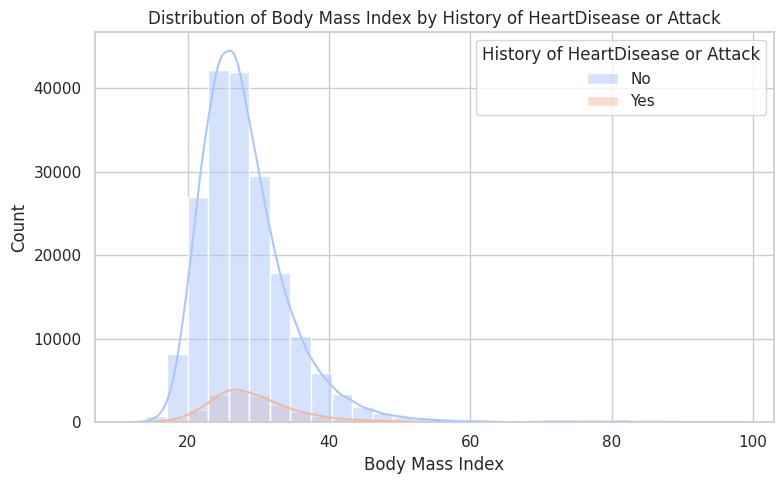

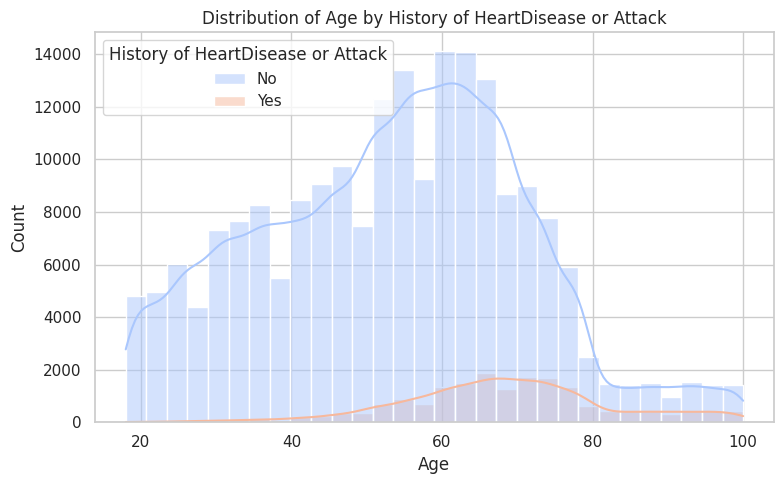


📊 กำลังพล็อตตัวแปรที่เป็นหมวดหมู่ (Categorical)...


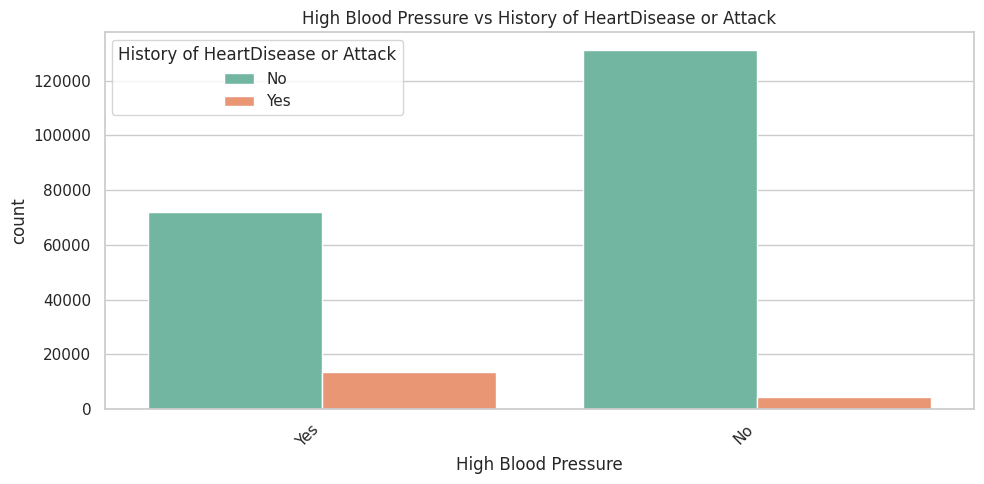

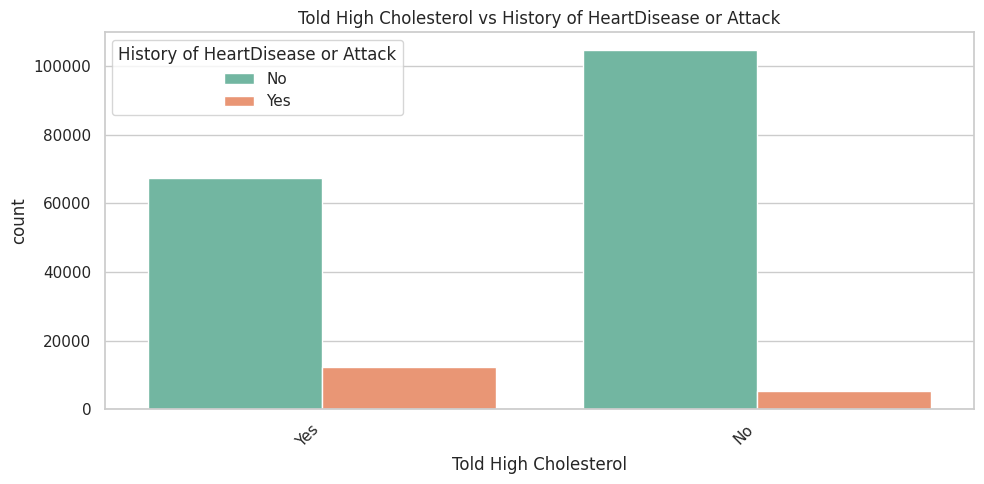

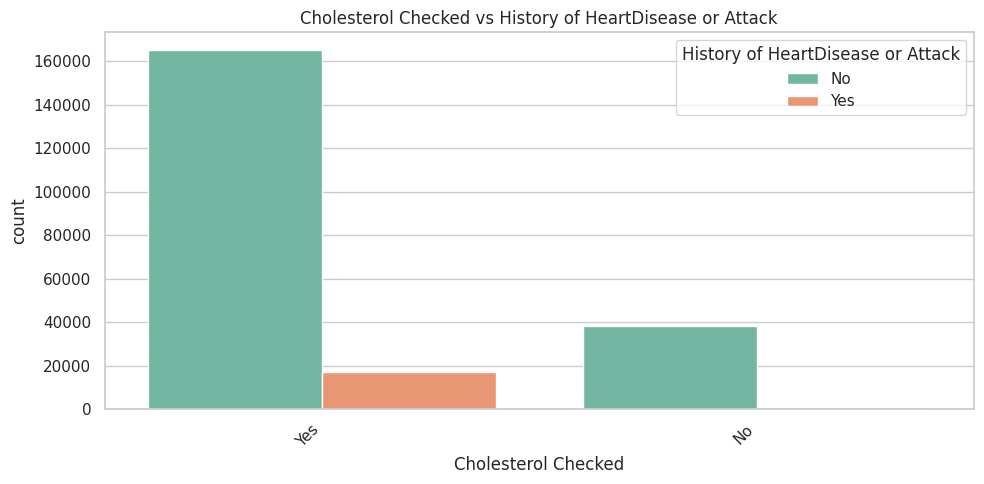

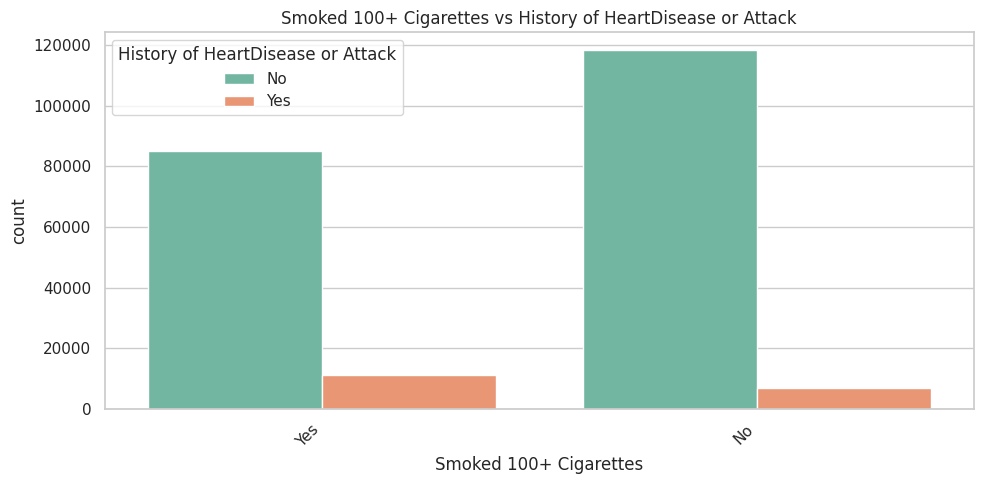

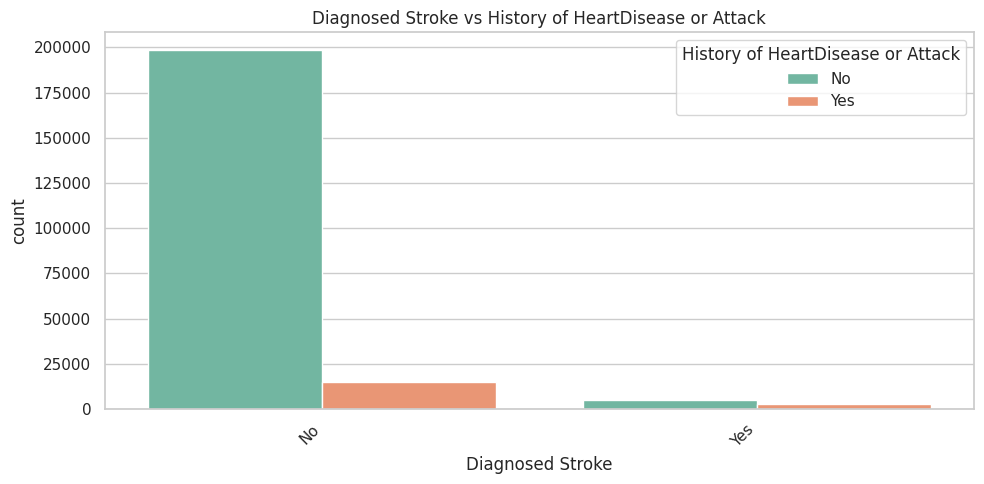

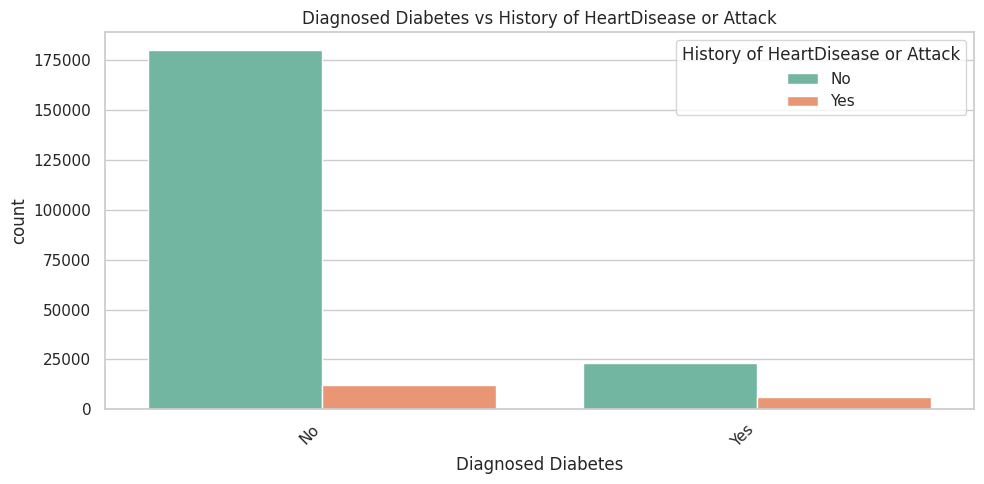

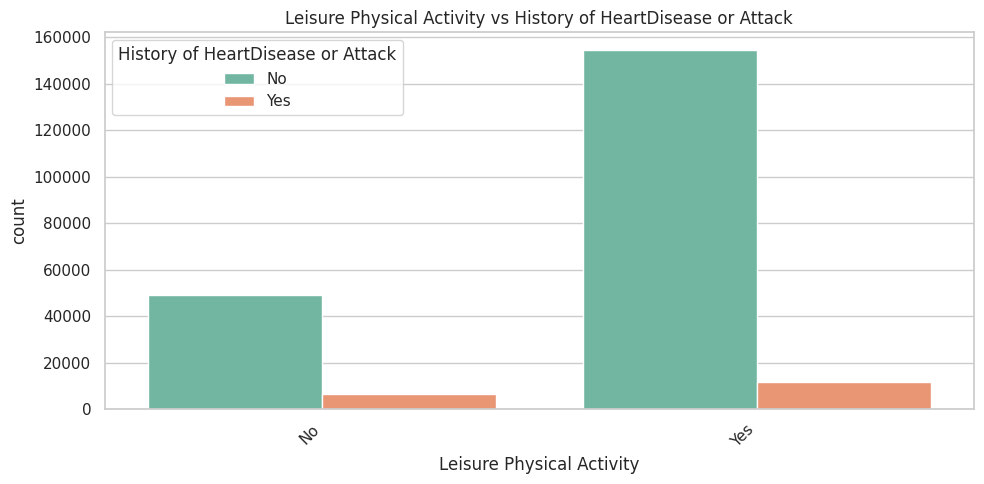

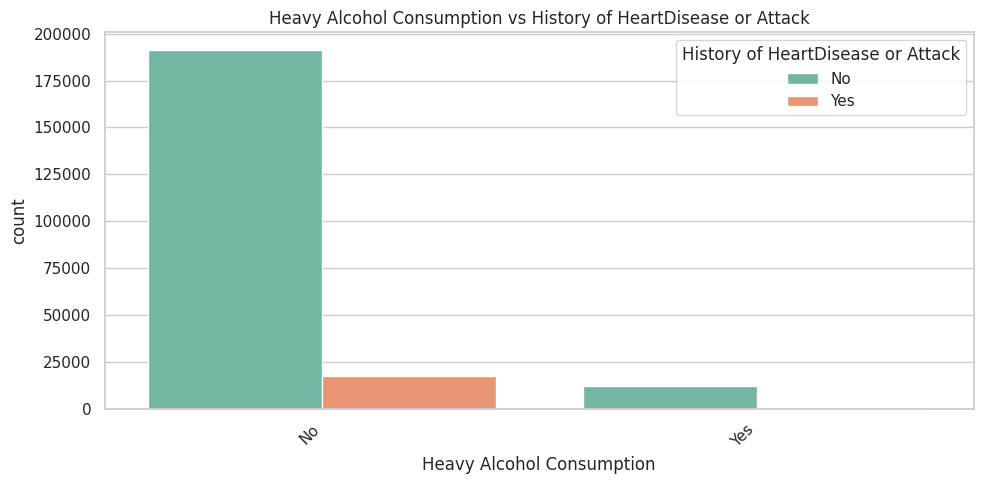

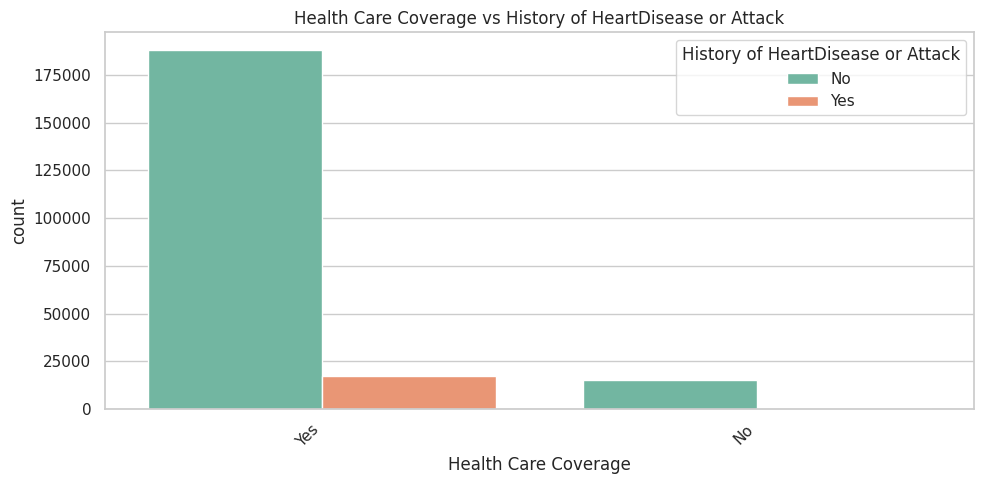

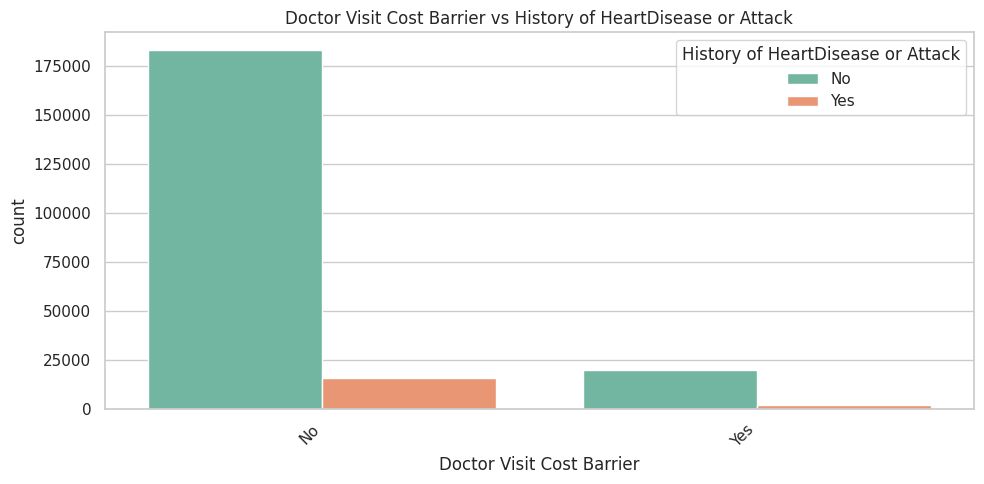

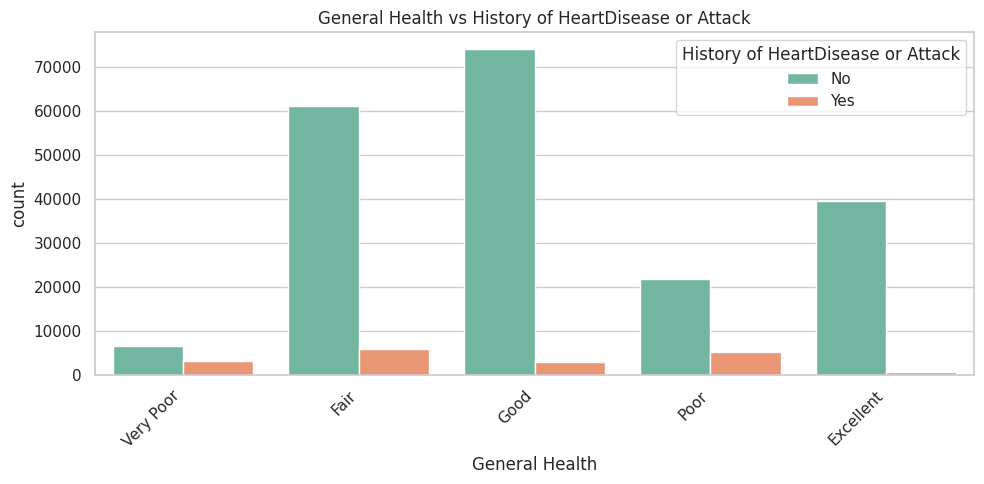

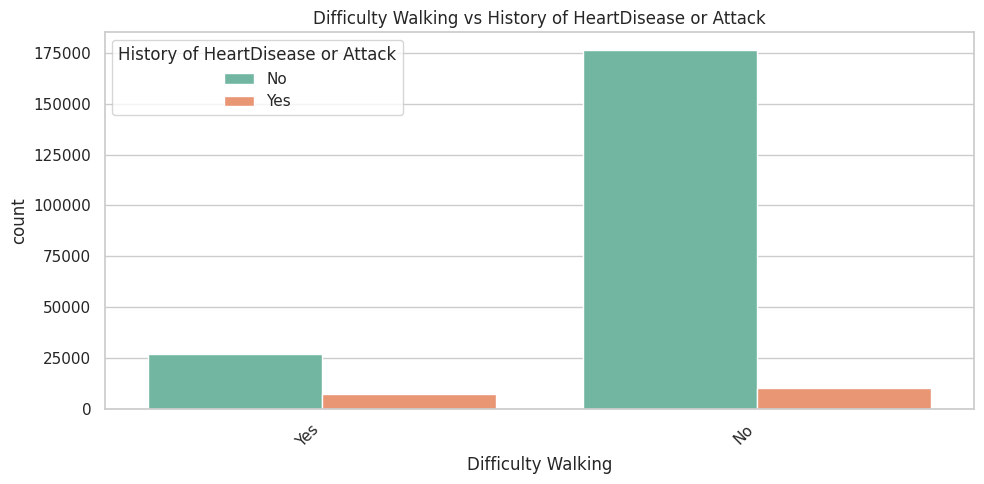

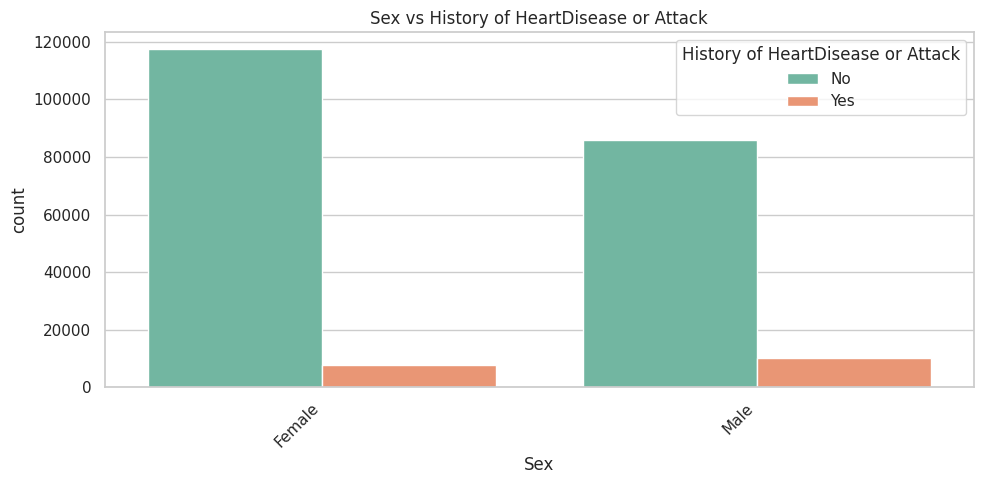

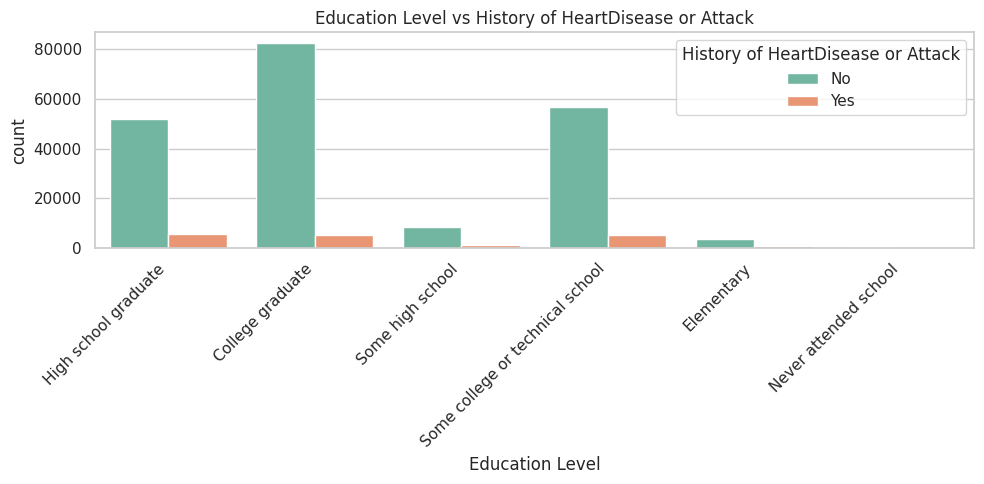

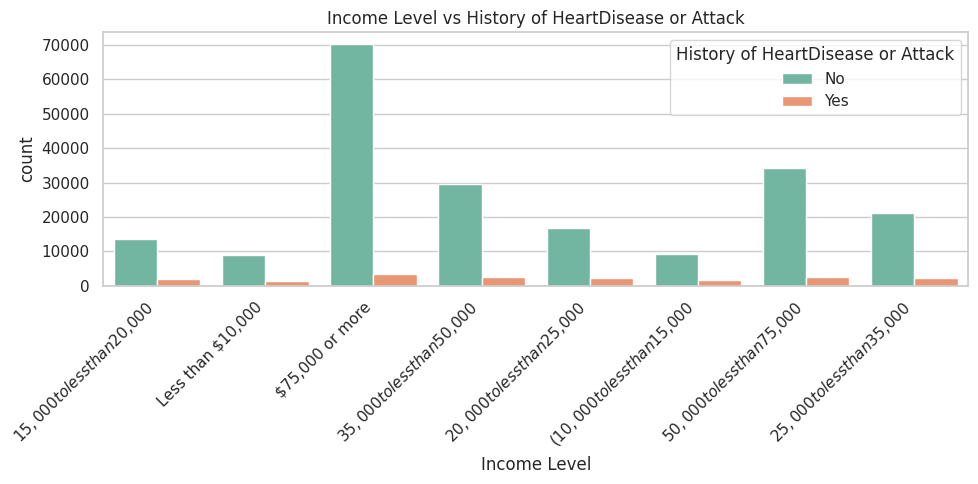

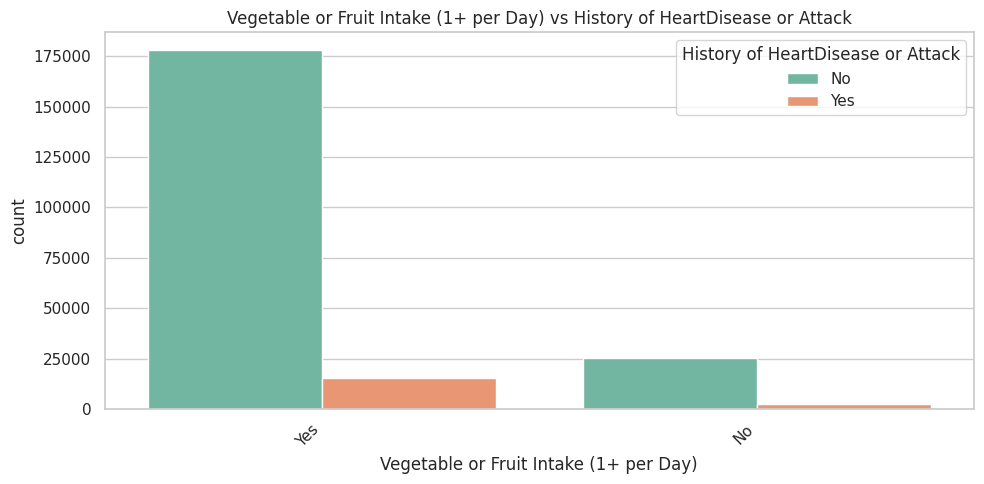

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# ตั้งค่าสไตล์
sns.set_theme(style="whitegrid")

# สร้าง DataFrame ใหม่สำหรับ EDA โดยตัดคอลัมน์ 'ID' ทิ้ง เพราะไม่มีผลต่อการวิเคราะห์
if 'ID' in train_df.columns:
    eda_df = train_df.drop('ID', axis=1)
else:
    eda_df = train_df.copy()

# กำหนดคอลัมน์เป้าหมาย
target_col = 'History of HeartDisease or Attack'

# แยกตัวแปรที่เป็น ตัวเลข (Numeric) และ ข้อความ (Categorical)
numeric_cols = eda_df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = eda_df.select_dtypes(include=['object', 'category']).columns

print("📊 กำลังพล็อตตัวแปรที่เป็นตัวเลข (Numeric)...")
for col in numeric_cols:
    plt.figure(figsize=(8, 5))
    # ใช้ Histogram เพื่อดูการกระจายตัวของตัวเลข
    sns.histplot(data=eda_df, x=col, hue=target_col, kde=True, bins=30, palette='coolwarm')
    plt.title(f'Distribution of {col} by {target_col}')
    plt.tight_layout()
    plt.show()

print("\n📊 กำลังพล็อตตัวแปรที่เป็นหมวดหมู่ (Categorical)...")
for col in categorical_cols:
    if col == target_col:
        continue # ข้ามคอลัมน์ Target เพราะเราเทียบกับตัวมันเองไม่ได้

    plt.figure(figsize=(10, 5))
    # ใช้ Countplot (กราฟแท่ง) เพื่อนับจำนวนแยกตามกลุ่ม
    sns.countplot(data=eda_df, x=col, hue=target_col, palette='Set2')
    plt.title(f'{col} vs {target_col}')
    plt.xticks(rotation=45, ha='right') # หมุนข้อความแกน X 45 องศาเพื่อไม่ให้ตัวหนังสือทับกัน
    plt.tight_layout()
    plt.show()

In [ ]:
import pandas as pd

# 1. สร้าง Copy ของข้อมูลเพื่อป้องกันความผิดพลาด
train_clean = train_df.copy()

# 2. ลบแถวที่ Target Variable (ประวัติโรคหัวใจ) มีค่าว่าง
train_clean = train_clean.dropna(subset=['History of HeartDisease or Attack'])

# 3. ลบแถวในคอลัมน์ที่มีค่าว่างแค่ 1-3 ค่า
cols_few_missing = [
    'Smoked 100+ Cigarettes', 'Diagnosed Diabetes',
    'Doctor Visit Cost Barrier', 'General Health', 'Difficulty Walking'
]
train_clean = train_clean.dropna(subset=cols_few_missing)

# 4. จัดการ Body Mass Index (BMI) เติมด้วยค่ามัธยฐาน (Median)
bmi_median = train_clean['Body Mass Index'].mean()
train_clean['Body Mass Index'].fillna(bmi_median, inplace=True)

# 5. จัดการ Told High Cholesterol เติมด้วยคำว่า 'Unknown'
train_clean['Told High Cholesterol'].fillna('Unknown', inplace=True)

# ---------------------------------------------------------
# ตรวจสอบผลลัพธ์หลังจากจัดการค่าว่าง
print("✅ จำนวนค่าว่างที่เหลืออยู่หลังทำ Preprocessing:")
print(train_clean.isnull().sum())
print("-" * 40)
print(f"📌 ขนาดของข้อมูลที่พร้อมใช้งาน: {train_clean.shape}")

/tmp/ipykernel_3066/3910316449.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_clean['Body Mass Index'].fillna(bmi_median, inplace=True)
/tmp/ipykernel_3066/3910316449.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inp

✅ จำนวนค่าว่างที่เหลืออยู่หลังทำ Preprocessing:
ID                                        0
History of HeartDisease or Attack         0
High Blood Pressure                       0
Told High Cholesterol                     0
Cholesterol Checked                       0
Body Mass Index                           0
Smoked 100+ Cigarettes                    0
Diagnosed Stroke                          0
Diagnosed Diabetes                        0
Leisure Physical Activity                 0
Heavy Alcohol Consumption                 0
Health Care Coverage                      0
Doctor Visit Cost Barrier                 0
General Health                            0
Difficulty Walking                        0
Sex                                       0
Education Level                           0
Income Level                              0
Age                                       0
Vegetable or Fruit Intake (1+ per Day)    0
dtype: int64
----------------------------------------
📌 ขนาดของข้อมูลที่

In [ ]:
from sklearn.preprocessing import LabelEncoder

# 1. สร้าง Copy เพื่อป้องกันข้อมูลต้นฉบับเสียหาย
train_encoded = train_clean.copy()

# 2. สร้าง Dictionary เพื่อเก็บ Object ของ LabelEncoder ไว้ (จำเป็นมากตอนนำไปแปลง Test Set ให้เป็นมาตรฐานเดียวกัน)
label_encoders = {}

# 3. ดึงชื่อคอลัมน์ทั้งหมดที่เป็นข้อความ (object)
categorical_cols = train_encoded.select_dtypes(include=['object']).columns

# 4. วนลูปแปลงข้อความเป็นตัวเลขทีละคอลัมน์
for col in categorical_cols:
    if col != 'ID': # ข้ามคอลัมน์ ID เพราะเป็นแค่รหัสประจำตัว ไม่ได้ใช้ในการพยากรณ์
        le = LabelEncoder()
        # แปลงข้อความเป็นตัวเลข
        train_encoded[col] = le.fit_transform(train_encoded[col].astype(str))
        # เก็บ LabelEncoder ของคอลัมน์นี้ไว้
        label_encoders[col] = le

# ---------------------------------------------------------
# ตรวจสอบผลลัพธ์
print("✅ ตัวอย่างข้อมูลหลังจากแปลงเป็นตัวเลขแล้ว (5 แถวแรก):")
display(train_encoded.head())

print("\n📊 ตรวจสอบประเภทข้อมูล (Data Types) ปัจจุบัน:")
print(train_encoded.dtypes)

✅ ตัวอย่างข้อมูลหลังจากแปลงเป็นตัวเลขแล้ว (5 แถวแรก):


,ID,History of HeartDisease or Attack,High Blood Pressure,Told High Cholesterol,Cholesterol Checked,Body Mass Index,Smoked 100+ Cigarettes,Diagnosed Stroke,Diagnosed Diabetes,Leisure Physical Activity,Heavy Alcohol Consumption,Health Care Coverage,Doctor Visit Cost Barrier,General Health,Difficulty Walking,Sex,Education Level,Income Level,Age,Vegetable or Fruit Intake (1+ per Day)
0,train_000001,0,1,2,1,40.68,1,0,0,0,0,1,0,4,1,0,2,0,64,1
1,train_000002,0,0,0,0,24.36,1,0,0,1,0,0,1,1,0,0,0,7,50,0
2,train_000003,0,1,2,1,27.33,0,0,0,0,0,1,1,4,1,0,2,5,61,1
3,train_000004,0,1,0,1,27.01,0,0,0,1,0,1,0,2,0,0,5,3,74,1
5,train_000006,0,1,2,1,25.11,1,0,0,1,0,1,0,2,0,1,0,5,67,1



📊 ตรวจสอบประเภทข้อมูล (Data Types) ปัจจุบัน:
ID                                         object
History of HeartDisease or Attack           int64
High Blood Pressure                         int64
Told High Cholesterol                       int64
Cholesterol Checked                         int64
Body Mass Index                           float64
Smoked 100+ Cigarettes                      int64
Diagnosed Stroke                            int64
Diagnosed Diabetes                          int64
Leisure Physical Activity                   int64
Heavy Alcohol Consumption                   int64
Health Care Coverage                        int64
Doctor Visit Cost Barrier                   int64
General Health                              int64
Difficulty Walking                          int64
Sex                                         int64
Education Level                             int64
Income Level                                int64
Age                                         int64
Vege

/tmp/ipykernel_3066/2703254170.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importances, x='Importance', y='Feature', palette='viridis')


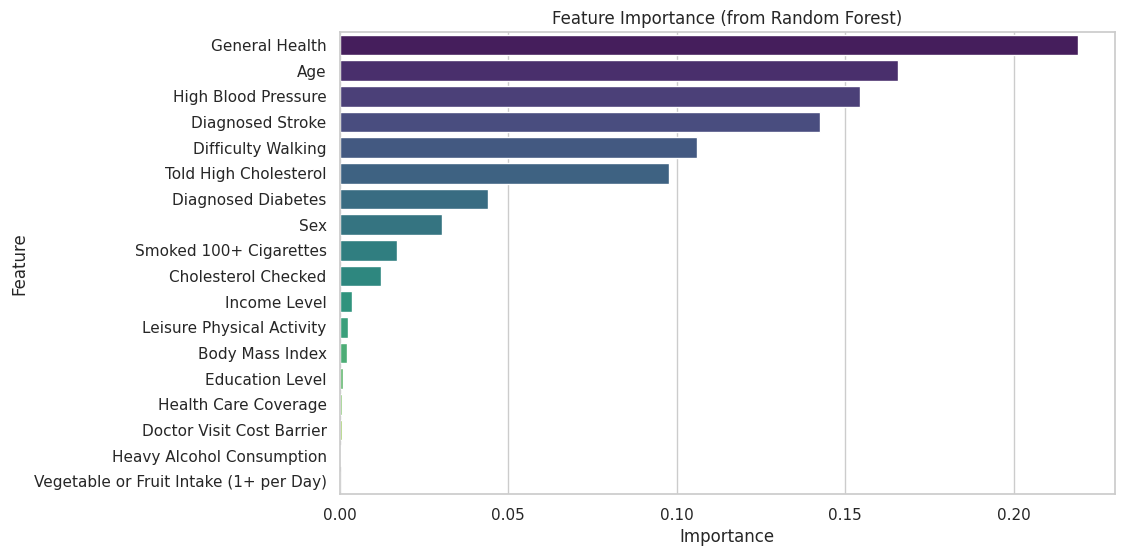

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# เตรียม X และ y ชั่วคราวสำหรับการหาความสำคัญ (ตัด ID ออก)
X_temp = train_encoded.drop(['History of HeartDisease or Attack', 'ID'], axis=1)
y_temp = train_encoded['History of HeartDisease or Attack']

# สร้างโมเดล Random Forest เบื้องต้น
rf_quick = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5)
rf_quick.fit(X_temp, y_temp)

# ดึงค่าความสำคัญของตัวแปรออกมา
feature_importances = pd.DataFrame({
    'Feature': X_temp.columns,
    'Importance': rf_quick.feature_importances_
}).sort_values(by='Importance', ascending=False)

# พล็อตกราฟ
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importances, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance (from Random Forest)')
plt.show()

In [ ]:
# 1. กำหนดเกณฑ์ (Threshold) ว่าจะเก็บเฉพาะตัวแปรที่คะแนนมากกว่า 0.01
threshold = 0.01

# 2. ดึงรายชื่อคอลัมน์ที่ผ่านเกณฑ์
important_features = feature_importances[feature_importances['Importance'] > threshold]['Feature'].tolist()

print(f"✅ จำนวนตัวแปรที่ถูกเลือก: {len(important_features)} ตัวแปร")
print("รายชื่อตัวแปรที่นำไปใช้ต่อ:", important_features)

# 3. ดึงรายชื่อคอลัมน์ที่ถูกตัดทิ้ง (เพื่อดูว่ามีอะไรบ้าง)
dropped_features = feature_importances[feature_importances['Importance'] <= threshold]['Feature'].tolist()
print("\n🗑️ ตัวแปรที่ถูกตัดทิ้ง (คะแนนน้อยเกินไป):", dropped_features)

# 4. สร้าง DataFrame ใหม่ที่เก็บเฉพาะคอลัมน์ที่สำคัญ + คอลัมน์ Target + ID
cols_to_keep = important_features + ['History of HeartDisease or Attack', 'ID']
train_selected = train_encoded[cols_to_keep]

print("-" * 40)
print(f"📊 ขนาดของข้อมูลหลังจากทำ Feature Selection: {train_selected.shape}")

✅ จำนวนตัวแปรที่ถูกเลือก: 10 ตัวแปร
รายชื่อตัวแปรที่นำไปใช้ต่อ: ['General Health', 'Age', 'High Blood Pressure', 'Diagnosed Stroke', 'Difficulty Walking', 'Told High Cholesterol', 'Diagnosed Diabetes', 'Sex', 'Smoked 100+ Cigarettes', 'Cholesterol Checked']

🗑️ ตัวแปรที่ถูกตัดทิ้ง (คะแนนน้อยเกินไป): ['Income Level', 'Leisure Physical Activity', 'Body Mass Index', 'Education Level', 'Health Care Coverage', 'Doctor Visit Cost Barrier', 'Heavy Alcohol Consumption', 'Vegetable or Fruit Intake (1+ per Day)']
----------------------------------------
📊 ขนาดของข้อมูลหลังจากทำ Feature Selection: (221382, 12)


In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 8.0 MB/s eta 0:00:00


In [ ]:
from sklearn.model_selection import train_test_split
import optuna
import xgboost as xgb
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_score
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# ==========================================
# 1. อัปเดต X และ y ด้วยข้อมูลที่ผ่านการคัด Feature แล้ว
# ==========================================
X = train_selected.drop(['History of HeartDisease or Attack', 'ID'], axis=1)
y = train_selected['History of HeartDisease or Attack']

# แบ่งข้อมูลเป็น Train Set และ Validation Set ใหม่
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("📊 ขนาดของ X_train (หลังคัด Feature):", X_train.shape)
print("-" * 40)

# ==========================================
# 2. ใช้ Optuna หาพารามิเตอร์ที่ดีที่สุด
# ==========================================
def objective(trial):
    # กำหนดช่วงของ Hyperparameters
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0.0, 5.0),
        'eval_metric': 'auc',
        'random_state': 42,
        'n_jobs': -1 # ใช้ CPU เต็มที่
    }

    xgb_model = xgb.XGBClassifier(**params)

    # Pipeline (SMOTE -> XGBoost)
    pipeline = ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('xgb', xgb_model)
    ])

    # Cross-Validation 3 Fold
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)

    return np.mean(scores)

print("⏳ กำลังค้นหา Hyperparameters ที่ดีที่สุดด้วย Optuna (อาจใช้เวลาสักครู่)...")
study = optuna.create_study(direction='maximize')
# รัน 10 รอบ (หรือปรับเพิ่มเป็น 20-30 รอบได้ถ้าต้องการความแม่นยำขึ้น)
study.optimize(objective, n_trials=10)

print("\n✅ ค้นหาเสร็จสิ้น!")
print("-" * 40)
print(f"⭐ ค่า ROC-AUC ที่ดีที่สุดที่ทำได้: {study.best_value:.4f}")
print("⭐ พารามิเตอร์ที่ดีที่สุด (Best Parameters):")
for key, value in study.best_params.items():
    print(f"   - {key}: {value}")
print("-" * 40)

[I 2026-04-03 16:30:44,965] A new study created in memory with name: no-name-82e299d1-9e57-4eab-847c-20a084b51768


📊 ขนาดของ X_train (หลังคัด Feature): (177105, 10)
----------------------------------------
⏳ กำลังค้นหา Hyperparameters ที่ดีที่สุดด้วย Optuna (อาจใช้เวลาสักครู่)...


[I 2026-04-03 16:31:21,066] Trial 0 finished with value: 0.8543471447919684 and parameters: {'n_estimators': 131, 'max_depth': 5, 'learning_rate': 0.11269738571748031, 'subsample': 0.6952571211377288, 'colsample_bytree': 0.9231995090557332, 'min_child_weight': 9, 'gamma': 4.384342747703515}. Best is trial 0 with value: 0.8543471447919684.
[I 2026-04-03 16:31:58,956] Trial 1 finished with value: 0.8530403234712385 and parameters: {'n_estimators': 261, 'max_depth': 6, 'learning_rate': 0.028476291688046967, 'subsample': 0.6380930363733027, 'colsample_bytree': 0.9820525362399425, 'min_child_weight': 5, 'gamma': 2.333681428858245}. Best is trial 0 with value: 0.8543471447919684.
[I 2026-04-03 16:32:13,800] Trial 2 finished with value: 0.8552814757083868 and parameters: {'n_estimators': 110, 'max_depth': 4, 'learning_rate': 0.036075392918502, 'subsample': 0.8170837313161783, 'colsample_bytree': 0.6139521755241321, 'min_child_weight': 9, 'gamma': 3.875413458145094}. Best is trial 2 with value


✅ ค้นหาเสร็จสิ้น!
----------------------------------------
⭐ ค่า ROC-AUC ที่ดีที่สุดที่ทำได้: 0.8556
⭐ พารามิเตอร์ที่ดีที่สุด (Best Parameters):
   - n_estimators: 140
   - max_depth: 3
   - learning_rate: 0.14180610423018336
   - subsample: 0.6762466036446686
   - colsample_bytree: 0.9065096044753089
   - min_child_weight: 8
   - gamma: 3.813641534275498
----------------------------------------


In [ ]:
import pandas as pd
import xgboost as xgb
from imblearn.over_sampling import SMOTE

# 1. พารามิเตอร์ที่ดีที่สุดจาก Optuna
best_params = {
    'n_estimators': 189,
    'max_depth': 3,
    'learning_rate': 0.05206254101094167,
    'subsample': 0.8888725277404408,
    'colsample_bytree': 0.9093558602691536,
    'min_child_weight': 2,
    'gamma': 2.003638676826807,
    'eval_metric': 'auc',
    'random_state': 42,
    'n_jobs': -1
}

# 2. เตรียมข้อมูล Train ทั้งหมด (X, y ที่คัดฟีเจอร์แล้ว) เพื่อเทรนโมเดลตัวจริง
print("⚖️ กำลังทำ SMOTE ปรับสมดุลข้อมูลทั้งหมด...")
smote = SMOTE(random_state=42)
# สังเกตว่าเราใช้ตัวแปร X และ y เต็มๆ แทนที่จะเป็นแค่ X_train เพื่อให้โมเดลได้เรียนรู้ข้อมูลเยอะที่สุด
X_smote, y_smote = smote.fit_resample(X, y)

print("🚀 กำลังเทรนโมเดล XGBoost ตัวสุดท้าย...")
final_xgb = xgb.XGBClassifier(**best_params)
final_xgb.fit(X_smote, y_smote)

# ==========================================
# 3. เตรียมข้อมูล Test Set
print("⚙️ กำลังเตรียมข้อมูล Test Set...")
test_clean = test_df.copy()

# เติมค่าว่างเหมือนตอนทำ Train
test_clean['Body Mass Index'].fillna(bmi_median, inplace=True)
test_clean['Told High Cholesterol'].fillna('Unknown', inplace=True)

for col in cols_few_missing:
    if col in test_clean.columns:
        mode_val = train_clean[col].mode()[0]
        test_clean[col].fillna(mode_val, inplace=True)

# แปลงข้อความเป็นตัวเลข (Label Encoding)
test_encoded = test_clean.copy()
for col in categorical_cols:
    if col != 'ID' and col in test_encoded.columns:
        le = label_encoders[col] # ใช้ Dictionary ที่เราเก็บไว้ตอนต้น
        test_encoded[col] = le.transform(test_encoded[col].astype(str))

# **สำคัญมาก**: เลือกเฉพาะคอลัมน์สำคัญที่โมเดลต้องการ
X_test_final = test_encoded[important_features]

# ==========================================
# 4. ทำนายผล
print("🔮 กำลังทำนายผลบน Test Set...")
predictions = final_xgb.predict(X_test_final)

# แปลงเลข 1 ให้เป็น "Yes" และเลข 0 ให้เป็น "No" เพื่อส่งคำตอบ
pred_labels = ["Yes" if p == 1 else "No" for p in predictions]

# 5. สร้างไฟล์ Submission
submission = pd.DataFrame({
    "ID": test_df["ID"],
    "History of HeartDisease or Attack": pred_labels
})

file_name = "submission_super_ai_final.csv"
submission.to_csv(file_name, index=False)

print("-" * 40)
print(f"✅ สร้างไฟล์ {file_name} เสร็จสมบูรณ์!")
print("📥 สามารถดาวน์โหลดจากแถบไฟล์ซ้ายมือของ Colab ไปส่งคะแนนได้เลยครับ ขอให้โชคดีนะครับ!")
display(submission.head())

⚖️ กำลังทำ SMOTE ปรับสมดุลข้อมูลทั้งหมด...
🚀 กำลังเทรนโมเดล XGBoost ตัวสุดท้าย...
⚙️ กำลังเตรียมข้อมูล Test Set...


/tmp/ipykernel_3066/349946482.py:35: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test_clean['Body Mass Index'].fillna(bmi_median, inplace=True)
/tmp/ipykernel_3066/349946482.py:36: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplac

🔮 กำลังทำนายผลบน Test Set...
----------------------------------------
✅ สร้างไฟล์ submission_super_ai_final.csv เสร็จสมบูรณ์!
📥 สามารถดาวน์โหลดจากแถบไฟล์ซ้ายมือของ Colab ไปส่งคะแนนได้เลยครับ ขอให้โชคดีนะครับ!


,ID,History of HeartDisease or Attack
0,test_000001,No
1,test_000002,No
2,test_000003,Yes
3,test_000004,No
4,test_000005,No


In [ ]:
import optuna
import xgboost as xgb
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import fbeta_score, make_scorer
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# 0. สร้าง F2 Scorer (เน้น Recall)
f2_scorer = make_scorer(fbeta_score, beta=2)

def objective_xgb_f2(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0.0, 5.0),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1.0, 3.0), # 🌟 ช่วยดัน F2-Score
        'random_state': 42,
        'n_jobs': -1
    }

    xgb_model = xgb.XGBClassifier(**params)

    pipeline = ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('xgb', xgb_model)
    ])

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring=f2_scorer, n_jobs=-1)

    return np.mean(scores)

print("⏳ กำลังค้นหา Hyperparameters สำหรับ [XGBoost] (เป้าหมาย: Maximize F2-Score)...")
study_xgb_f2 = optuna.create_study(direction='maximize')
study_xgb_f2.optimize(objective_xgb_f2, n_trials=30) # ปรับเพิ่ม n_trials ได้

print("\n✅ [XGBoost] ค้นหาเสร็จสิ้น!")
print(f"⭐ ค่า F2-Score ที่ดีที่สุด: {study_xgb_f2.best_value:.4f}")
print("-" * 40)

[I 2026-04-03 16:34:50,044] A new study created in memory with name: no-name-a824b326-bfc6-4feb-86d6-9c74f4335bcb


⏳ กำลังค้นหา Hyperparameters สำหรับ [XGBoost] (เป้าหมาย: Maximize F2-Score)...


[I 2026-04-03 16:35:40,014] Trial 0 finished with value: 0.4848696281472472 and parameters: {'n_estimators': 285, 'max_depth': 9, 'learning_rate': 0.028083184918124594, 'subsample': 0.7850990606469046, 'colsample_bytree': 0.6070200146079469, 'min_child_weight': 9, 'gamma': 4.15547344044359, 'scale_pos_weight': 2.249069314908805}. Best is trial 0 with value: 0.4848696281472472.
[I 2026-04-03 16:36:06,038] Trial 1 finished with value: 0.4616649725967591 and parameters: {'n_estimators': 214, 'max_depth': 4, 'learning_rate': 0.019687204241863408, 'subsample': 0.8097857850531378, 'colsample_bytree': 0.6937399420896202, 'min_child_weight': 4, 'gamma': 3.3878319189462927, 'scale_pos_weight': 2.5642917339958244}. Best is trial 0 with value: 0.4848696281472472.
[I 2026-04-03 16:36:29,206] Trial 2 finished with value: 0.5229373549756051 and parameters: {'n_estimators': 101, 'max_depth': 9, 'learning_rate': 0.027740774341560984, 'subsample': 0.7616982158148486, 'colsample_bytree': 0.8175369063944


✅ [XGBoost] ค้นหาเสร็จสิ้น!
⭐ ค่า F2-Score ที่ดีที่สุด: 0.5291
----------------------------------------


In [ ]:
import pandas as pd
import xgboost as xgb
from imblearn.over_sampling import SMOTE

# 1. ทำ SMOTE ปรับสมดุลข้อมูลทั้งหมด (X, y ที่ผ่าน Feature Selection แล้ว)
print("⚖️ กำลังทำ SMOTE ปรับสมดุลข้อมูลทั้งหมด...")
smote = SMOTE(random_state=42)
X_smote_xgb, y_smote_xgb = smote.fit_resample(X, y)

# 2. ดึง Best Parameters จาก Optuna มาใช้ และเพิ่มค่าพื้นฐาน
print("🚀 กำลังเทรนโมเดล XGBoost ตัวสุดท้ายด้วย Best Parameters (เน้น F2-Score)...")
final_xgb_params = study_xgb_f2.best_params.copy()
final_xgb_params.update({'random_state': 42, 'n_jobs': -1})

final_xgb = xgb.XGBClassifier(**final_xgb_params)
final_xgb.fit(X_smote_xgb, y_smote_xgb)

# 3. ทำนายและสร้างไฟล์ Submission
print("🔮 กำลังทำนายผลบน Test Set...")
predictions_xgb = final_xgb.predict(X_test_final)

# แปลงเลข 1 เป็น "Yes" และ 0 เป็น "No"
pred_labels_xgb = ["Yes" if p == 1 else "No" for p in predictions_xgb]

submission_xgb = pd.DataFrame({
    "ID": test_df["ID"],
    "History of HeartDisease or Attack": pred_labels_xgb
})

file_name_xgb = "submission_xgboost_f2_final.csv"
submission_xgb.to_csv(file_name_xgb, index=False)

print("-" * 40)
print(f"✅ สร้างไฟล์ {file_name_xgb} เสร็จสมบูรณ์!")
print("📥 ดาวน์โหลดไฟล์จากแถบซ้ายมือไปส่งคำตอบได้เลยครับ")
display(submission_xgb.head())

⚖️ กำลังทำ SMOTE ปรับสมดุลข้อมูลทั้งหมด...
🚀 กำลังเทรนโมเดล XGBoost ตัวสุดท้ายด้วย Best Parameters (เน้น F2-Score)...
🔮 กำลังทำนายผลบน Test Set...
----------------------------------------
✅ สร้างไฟล์ submission_xgboost_f2_final.csv เสร็จสมบูรณ์!
📥 ดาวน์โหลดไฟล์จากแถบซ้ายมือไปส่งคำตอบได้เลยครับ


,ID,History of HeartDisease or Attack
0,test_000001,Yes
1,test_000002,No
2,test_000003,Yes
3,test_000004,No
4,test_000005,No
